In [27]:
# Importing Libraries
import os
import kagglehub
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from xgboost import XGBClassifier

import joblib

In [28]:
# Step 2: Loading Dataset
path = kagglehub.dataset_download("algozee/credit-risk-and-loan-default-analysis-dataset")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in dataset folder:")
for f in files:
    print(f)


Path to dataset files: C:\Users\Aditya\.cache\kagglehub\datasets\algozee\credit-risk-and-loan-default-analysis-dataset\versions\1
Files in dataset folder:
loan_risk_prediction_dataset.csv


In [29]:
# Step 4: Load Dataset
csv_file = [f for f in files if f.endswith(".csv")][0]

file_path = os.path.join(path, csv_file)
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [30]:
df.head(5)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [31]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [32]:
df.sample(6)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
1017,42,79030.0,18630.0,497.0,38,Female,Masters,San Francisco,Self-Employed,0
3983,54,51244.0,2618.0,760.0,6,Male,NaN,San Francisco,Self-Employed,1
185,61,56220.0,19744.0,673.0,12,Male,High School,New York,Self-Employed,1
760,28,59078.0,7010.0,475.0,0,Female,Masters,Houston,Salaried,0
291,65,67567.0,26471.0,575.0,17,Female,High School,Chicago,Self-Employed,0
4941,56,84088.0,26634.0,638.0,27,Female,NaN,Chicago,Unemployed,0


In [33]:
# Step 5: Explore Dataset
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape of dataset: (5000, 10)

Columns:
 ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB
None

Missing Values:
Age                  0
Income             196
LoanAmount           0
CreditSc

In [34]:
from sklearn.impute import IterativeImputer, SimpleImputer

In [35]:
# Separate num. and cat. columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numeric Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'LoanApproved']
Categorical Columns: ['Gender', 'Education', 'City', 'EmploymentType']


In [36]:
target_col = "LoanApproved"

if target_col in numeric_cols:
    numeric_cols.remove(target_col)

if target_col in categorical_cols:
    categorical_cols.remove(target_col)

In [37]:
# Iterative Imputer for num. columns
iter_imputer = IterativeImputer(random_state=42)

df[numeric_cols] = iter_imputer.fit_transform(df[numeric_cols])

In [38]:
# Simple Imputer for cat. columns
cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [39]:
print("Missing Values After Imputation:")
print(df.isnull().sum())

Missing Values After Imputation:
Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64


In [40]:
# Encoding Target Variable
print("Unique values in target before encoding:", df[target_col].unique())

if df[target_col].dtype == "object":
    le_target = LabelEncoder()
    df[target_col] = le_target.fit_transform(df[target_col])

print("Unique values in target after encoding:", df[target_col].unique())

Unique values in target before encoding: [0 1]
Unique values in target after encoding: [0 1]


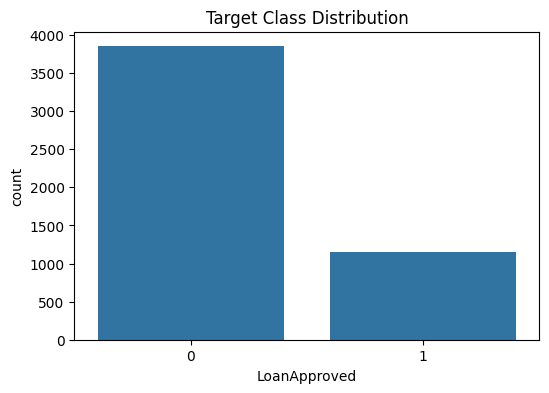

LoanApproved
0    3849
1    1151
Name: count, dtype: int64


In [41]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df[target_col])
plt.title("Target Class Distribution")
plt.show()

print(df[target_col].value_counts())

In [42]:
X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 9)
Target shape: (5000,)


In [43]:
print("Shape of raw features (before pipeline):", X.shape)

Shape of raw features (before pipeline): (5000, 9)


In [44]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (4000, 9)
X_test : (1000, 9)


In [45]:
# Feature Scaling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

In [46]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [47]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [48]:
# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC AUC  :", round(roc_auc, 4))

Accuracy : 0.961
Precision: 0.9526
Recall   : 0.8739
F1 Score : 0.9116
ROC AUC  : 0.9319


In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       770
           1       0.95      0.87      0.91       230

    accuracy                           0.96      1000
   macro avg       0.96      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000



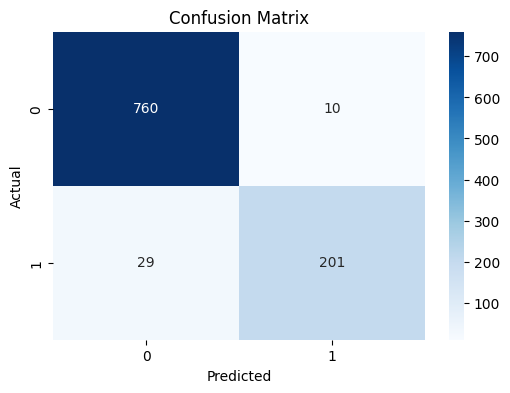

In [50]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

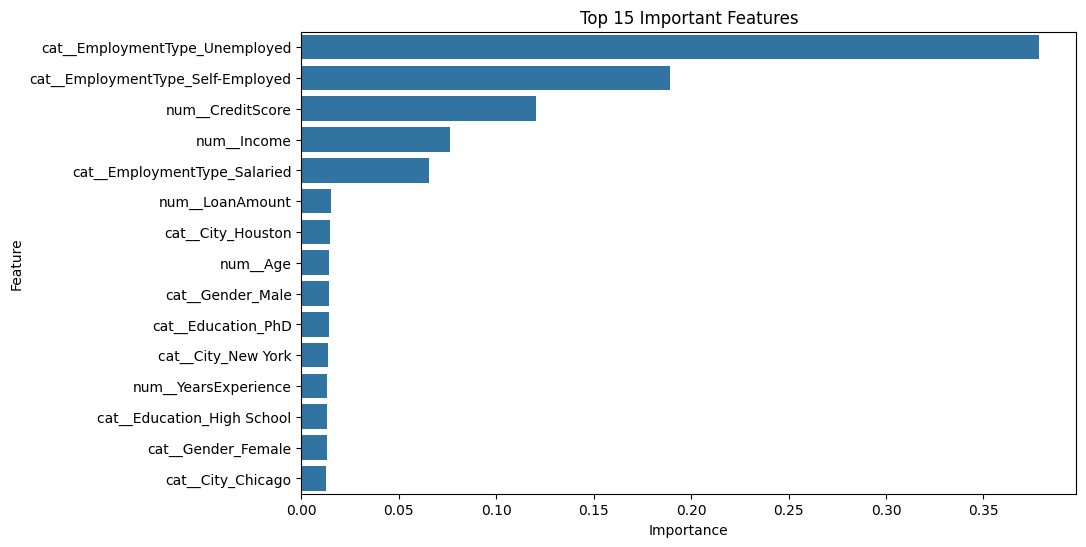

,Feature,Importance
17,cat__EmploymentType_Unemployed,0.378768
16,cat__EmploymentType_Self-Employed,0.189085
3,num__CreditScore,0.120225
1,num__Income,0.076045
15,cat__EmploymentType_Salaried,0.065601
2,num__LoanAmount,0.015068
12,cat__City_Houston,0.014776
0,num__Age,0.014177
6,cat__Gender_Male,0.014099
10,cat__Education_PhD,0.014047


In [51]:
# Feature Importance
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': pipeline.named_steps["model"].feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title("Top 15 Important Features")
plt.show()

importance_df.head(15)

In [52]:
# Save Model & Objects
joblib.dump(pipeline, "pipeline.pkl")
print("Saved files:")
print("- pipeline.pkl")

Saved files:
- pipeline.pkl
